# Fase 1.1 — Identificación de Fuentes de Datos Relevantes

**Proyecto:** Desarrollo de un Proyecto de Análisis de Datos y Modelo Predictivo para una Aplicación de Negocio
**Materia:** Análisis de Datos — Ingeniería de Sistemas
**Fecha:** Mayo de 2026

## 1. Introducción

La primera fase del proyecto consiste en **identificar fuentes de datos** que
sean adecuadas para abordar un problema de negocio real, evaluando su
pertinencia, calidad documentada, alcance y viabilidad técnica para soportar
las fases posteriores: análisis exploratorio (EDA), inteligencia de negocios
(BI) y modelado predictivo (AC).

Para esta entrega se preseleccionaron **cinco datasets públicos** alojados en
la plataforma Kaggle, todos provenientes de dominios con clara aplicabilidad
empresarial: *e-commerce*, *cadena de suministro*, *hotelería*, *retail* y
*aviación comercial*. El propósito de este notebook es:

1. Documentar cada dataset candidato (origen, estructura, licencia,
   problema de negocio, modelos predictivos viables).
2. Definir un conjunto de **criterios de selección** ponderados, alineados
   con la rúbrica de evaluación.
3. Construir una **matriz comparativa** que permita justificar de forma
   trazable cuál dataset se llevará a las siguientes fases del proyecto.

## 2. Objetivos del notebook

**Objetivo general**

Identificar, caracterizar y comparar fuentes de datos públicas relevantes
para el desarrollo de una solución analítica end-to-end, justificando la
selección de la fuente que será utilizada en las fases siguientes del
proyecto.

**Objetivos específicos**

- Describir cada dataset candidato en términos de origen, dominio,
  estructura, licencia y posibles aplicaciones de negocio.
- Definir criterios objetivos y ponderados para evaluar la idoneidad de
  cada fuente.
- Construir una matriz comparativa y una visualización que respalden la
  decisión.
- Dejar trazabilidad técnica para las fases de ETL, EDA, BI y modelado.


## 3. Metodología

El proceso de selección sigue cuatro pasos:

1. **Catalogación.** Para cada dataset se elabora una *ficha técnica* con
   metadatos clave (fuente, autor, registros aproximados, número de tablas,
   formato, variables relevantes, target potencial, licencia).
2. **Definición de criterios.** Se establecen siete criterios de evaluación
   con un peso porcentual asignado según su relevancia para los resultados
   de aprendizaje del proyecto (BI, AD, AC).
3. **Calificación.** Cada dataset recibe una puntuación de **1 a 5** en
   cada criterio. La calificación se basa en la documentación pública de
   cada fuente, no en una exploración del contenido (esa exploración se
   realiza en el notebook de ETL).
4. **Recomendación.** Se calcula una puntuación ponderada por dataset y
   se justifica el de mayor puntaje como candidato principal.

> Los datasets **no se descargan** en este notebook. La carga, perfilado y
> validación de calidad se realizan en el notebook de ETL.


## 4. Criterios de selección

Los siete criterios definidos buscan equilibrar las tres asignaturas
involucradas (Inteligencia de Negocios, Analítica de Datos y Aprendizaje
Computacional) y reflejar la rúbrica de evaluación.


In [1]:
import pandas as pd

criterios = pd.DataFrame([
    {
        "id": "C1",
        "criterio": "Relevancia para un problema de negocio claro",
        "peso_%": 20,
        "descripcion": "Qué tan directamente el dataset permite formular un problema de negocio "
                       "concreto y accionable (ej. predecir cancelaciones, detectar fraude)."
    },
    {
        "id": "C2",
        "criterio": "Volumen y riqueza de datos",
        "peso_%": 15,
        "descripcion": "Cantidad de registros y diversidad de variables, suficientes para entrenar "
                       "modelos supervisados sin caer en sobreajuste por escasez."
    },
    {
        "id": "C3",
        "criterio": "Complejidad relacional (apto para modelado dimensional / BI)",
        "peso_%": 15,
        "descripcion": "Existencia de múltiples tablas relacionadas que permitan diseñar un modelo "
                       "estrella/copo de nieve y ejercitar el componente de Inteligencia de Negocios."
    },
    {
        "id": "C4",
        "criterio": "Calidad y documentación de la fuente",
        "peso_%": 15,
        "descripcion": "Existencia de diccionario de datos, descripciones por columna, ejemplos de uso "
                       "y comunidad activa (notebooks, kernels) que respalden la fuente."
    },
    {
        "id": "C5",
        "criterio": "Aptitud para aprendizaje supervisado",
        "peso_%": 15,
        "descripcion": "Disponibilidad de una variable objetivo bien definida (regresión o "
                       "clasificación) y de features con buena señal predictiva."
    },
    {
        "id": "C6",
        "criterio": "Licencia y consideraciones éticas",
        "peso_%": 10,
        "descripcion": "Licencia abierta, datos anonimizados y bajo riesgo de exposición de información "
                       "personal sensible."
    },
    {
        "id": "C7",
        "criterio": "Viabilidad técnica (tamaño manejable, formato estándar)",
        "peso_%": 10,
        "descripcion": "Tamaño del archivo razonable para procesamiento local, formato CSV/UTF-8 y "
                       "facilidad de lectura con pandas."
    },
])

assert criterios["peso_%"].sum() == 100, "Los pesos deben sumar 100%"
criterios


,id,criterio,peso_%,descripcion
0,C1,Relevancia para un problema de negocio claro,20,Qué tan directamente el dataset permite formul...
1,C2,Volumen y riqueza de datos,15,Cantidad de registros y diversidad de variable...
2,C3,Complejidad relacional (apto para modelado dim...,15,Existencia de múltiples tablas relacionadas qu...
3,C4,Calidad y documentación de la fuente,15,"Existencia de diccionario de datos, descripcio..."
4,C5,Aptitud para aprendizaje supervisado,15,Disponibilidad de una variable objetivo bien d...
5,C6,Licencia y consideraciones éticas,10,"Licencia abierta, datos anonimizados y bajo ri..."
6,C7,"Viabilidad técnica (tamaño manejable, formato ...",10,Tamaño del archivo razonable para procesamient...


## 5. Catálogo de datasets candidatos

A continuación se presenta la ficha técnica de cada uno de los cinco
candidatos preseleccionados.


### 5.1. Brazilian E-Commerce Public Dataset by Olist

| Campo | Valor |
|---|---|
| **Fuente** | Kaggle — `olistbr/brazilian-ecommerce` |
| **URL** | https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce |
| **Proveedor** | Olist (marketplace brasileño) |
| **Período** | 2016 – 2018 |
| **Registros aprox.** | ~100.000 órdenes |
| **Estructura** | 9 archivos CSV relacionados (modelo relacional) |
| **Tamaño aprox.** | ~65 MB |
| **Formato** | CSV, codificación UTF-8 |
| **Licencia** | CC BY-NC-SA 4.0 |

**Tablas que componen el dataset**

- `olist_customers_dataset` — clientes y ubicación.
- `olist_orders_dataset` — órdenes con timestamps de compra, aprobación,
  envío y entrega.
- `olist_order_items_dataset` — ítems por orden, precio y flete.
- `olist_order_payments_dataset` — método y cuotas de pago.
- `olist_order_reviews_dataset` — reseñas con puntaje y comentario.
- `olist_products_dataset` — atributos del producto (categoría,
  dimensiones, peso).
- `olist_sellers_dataset` — vendedores y ubicación.
- `olist_geolocation_dataset` — coordenadas por código postal.
- `product_category_name_translation` — traducción ES/EN de categorías.

**Posibles problemas de negocio**

- Predicción del **tiempo real de entrega** vs. el estimado (regresión).
- Predicción del **puntaje de reseña** del cliente (clasificación o
  regresión ordinal).
- **Segmentación RFM** de clientes para campañas de fidelización.
- Pronóstico de **ventas por categoría** y por estado.

**Modelos predictivos viables**

- Regresión lineal / Random Forest Regressor para tiempos de entrega.
- Clasificación binaria (review ≥ 4) con Logistic Regression / XGBoost.
- Series de tiempo (Prophet, ARIMA) para demanda agregada.

**Fortalezas**

- Datos **reales y anonimizados** de un marketplace en operación.
- Estructura **multi-tabla** ideal para diseñar un modelo dimensional
  (hecho: orden, dimensiones: cliente, producto, vendedor, tiempo,
  geografía) — encaja perfectamente con BI.
- Ampliamente documentado, con cientos de notebooks de referencia.

**Limitaciones**

- Dataset cerrado en 2018; no refleja efectos post-pandemia.
- Reseñas en portugués (puede requerir traducción para análisis NLP).
- Licencia **no comercial** (uso académico permitido, comercial no).


### 5.2. DataCo Smart Supply Chain for Big Data Analysis

| Campo | Valor |
|---|---|
| **Fuente** | Kaggle — `shashwatwork/dataco-smart-supply-chain-for-big-data-analysis` |
| **URL** | https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis |
| **Proveedor** | DataCo Global (sintético/operacional) |
| **Período** | 2015 – 2018 (aprox.) |
| **Registros aprox.** | ~180.000 transacciones |
| **Estructura** | Un archivo principal CSV + archivo de logs de acceso |
| **Tamaño aprox.** | ~90 MB |
| **Formato** | CSV (latin-1) |
| **Licencia** | CC BY-SA 4.0 |

**Variables destacadas**

- Identificadores: `Order Id`, `Customer Id`, `Product Card Id`.
- Logística: `Days for shipping (real)`, `Days for shipment (scheduled)`,
  `Late_delivery_risk`, `Shipping Mode`, `Delivery Status`.
- Cliente: segmento, país, ciudad, estado.
- Negocio: `Sales`, `Order Item Discount`, `Order Profit Per Order`,
  `Order Item Total`.
- Posible target de fraude: `Order Status` con valor `SUSPECTED_FRAUD`.

**Posibles problemas de negocio**

- **Predicción de retraso de entrega** (clasificación binaria sobre
  `Late_delivery_risk` o regresión sobre días reales vs. programados).
- **Detección de fraude** sobre `Order Status`.
- Análisis de **rentabilidad por segmento, región y categoría**.

**Modelos predictivos viables**

- Logistic Regression, Random Forest, XGBoost para clasificación binaria.
- Regresión para `Order Profit Per Order`.

**Fortalezas**

- Cubre el **ciclo completo de la cadena de suministro**: orden, envío,
  pago, devolución.
- Variables ya preparadas como flags binarias (atajo para clasificación
  supervisada).
- Buena distribución geográfica (más de 160 países).

**Limitaciones**

- Origen no del todo claro (parcialmente sintético); requiere
  documentar este punto en consideraciones éticas.
- Una sola tabla amplia (≈53 columnas): menor riqueza relacional para
  modelado dimensional.
- Codificación `latin-1` y nombres de columnas con espacios y mayúsculas
  exigen un saneamiento agresivo en ETL.


### 5.3. Hotel Booking Demand

| Campo | Valor |
|---|---|
| **Fuente** | Kaggle — `jessemostipak/hotel-booking-demand` |
| **URL** | https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand |
| **Proveedor** | Antonio, Almeida y Nunes (2019) — *Data in Brief* |
| **Período** | Julio 2015 – Agosto 2017 |
| **Registros aprox.** | ~119.000 reservas |
| **Estructura** | Un archivo CSV (`hotel_bookings.csv`) |
| **Tamaño aprox.** | ~16 MB |
| **Formato** | CSV, UTF-8 |
| **Licencia** | CC0 — Dominio público |

**Variables destacadas**

- Tipo de hotel (`City Hotel` / `Resort Hotel`).
- `lead_time`, `arrival_date_*`, `stays_in_*_nights`, `adults`,
  `children`, `babies`, `country`, `market_segment`,
  `distribution_channel`.
- Económicas: `adr` (average daily rate), `deposit_type`, `customer_type`.
- Target: `is_canceled` (binaria).

**Posibles problemas de negocio**

- **Predicción de cancelaciones** de reservas (clasificación binaria).
- Pronóstico de **demanda hotelera** por temporada y país.
- Optimización de la **tarifa promedio diaria (ADR)**.
- Segmentación por canal de distribución y tipo de cliente.

**Modelos predictivos viables**

- Logistic Regression, Random Forest, Gradient Boosting para
  cancelaciones.
- Regresión para predecir ADR.

**Fortalezas**

- Dataset proveniente de una **publicación científica revisada**.
- Licencia **CC0** (uso libre, incluso comercial).
- Target binario claramente definido y balanceado (~37 % de
  cancelaciones).

**Limitaciones**

- Una sola tabla → modelo de datos plano, menos enriquecedor para BI.
- Información de país en código ISO de 3 letras (requiere catálogo
  externo para mapeos).
- Algunos campos con missing values significativos (`agent`, `company`).


### 5.4. Superstore Sales Dataset

| Campo | Valor |
|---|---|
| **Fuente** | Kaggle — `laibaanwer/superstore-sales-dataset` |
| **URL** | https://www.kaggle.com/datasets/laibaanwer/superstore-sales-dataset |
| **Proveedor** | Tableau Sample Superstore (replica) |
| **Período** | 2014 – 2018 (4 años de ventas) |
| **Registros aprox.** | ~10.000 órdenes |
| **Estructura** | Un archivo CSV |
| **Tamaño aprox.** | ~3 MB |
| **Formato** | CSV |
| **Licencia** | Public Domain (replica del sample de Tableau) |

**Variables destacadas**

- `Order ID`, `Order Date`, `Ship Date`, `Ship Mode`.
- Cliente: `Customer ID`, `Segment`.
- Geografía: `Country`, `Region`, `State`, `City`, `Postal Code`.
- Producto: `Category`, `Sub-Category`, `Product Name`.
- Negocio: `Sales`, `Quantity`, `Discount`, `Profit`.

**Posibles problemas de negocio**

- Pronóstico de **ventas mensuales/trimestrales** (series de tiempo).
- Predicción de **rentabilidad** por producto/segmento.
- Identificación de productos con **descuento dañino** (descuento alto +
  utilidad negativa).

**Modelos predictivos viables**

- Regresión lineal, Random Forest Regressor, XGBoost para `Profit`.
- Modelos de series de tiempo (ARIMA, Prophet) para `Sales` agregadas.

**Fortalezas**

- **Limpio y simple**, ideal como dataset didáctico.
- Cobertura geográfica granular (estado, ciudad, código postal).
- Excelente para construir un dashboard **vistoso** de BI.

**Limitaciones**

- **Volumen reducido** (~10k filas); puede limitar la complejidad de
  modelos de ML.
- Una sola tabla → estructura plana.
- Es un dataset **de ejemplo** (no representa una operación real).


### 5.5. Airline Passenger Satisfaction

| Campo | Valor |
|---|---|
| **Fuente** | Kaggle — `mysarahmadbhat/airline-passenger-satisfaction` |
| **URL** | https://www.kaggle.com/datasets/mysarahmadbhat/airline-passenger-satisfaction |
| **Proveedor** | Encuesta de aerolínea (anonimizada) |
| **Período** | No especificado |
| **Registros aprox.** | ~129.000 (split train/test) |
| **Estructura** | Dos archivos CSV (`train.csv`, `test.csv`) |
| **Tamaño aprox.** | ~6 MB |
| **Formato** | CSV |
| **Licencia** | CC0 — Dominio público |

**Variables destacadas**

- Demográficas: `Gender`, `Age`, `Customer Type` (loyal / disloyal).
- Vuelo: `Type of Travel` (business / personal), `Class`,
  `Flight Distance`, `Departure Delay`, `Arrival Delay`.
- 14 calificaciones de servicio (escala 0-5): `Inflight wifi service`,
  `Online boarding`, `Seat comfort`, `Cleanliness`, etc.
- Target: `satisfaction` (binaria: `satisfied` / `neutral or dissatisfied`).

**Posibles problemas de negocio**

- **Clasificación de satisfacción** del pasajero.
- Identificación de los **drivers de satisfacción** (importancia de
  features).
- Diseño de **acciones de mejora** por segmento de cliente.

**Modelos predictivos viables**

- Logistic Regression, Random Forest, XGBoost, Redes neuronales simples.
- Análisis de importancia con SHAP.

**Fortalezas**

- Target binario bien balanceado (~57 % insatisfechos).
- Variables predictoras de alta señal (las calificaciones explican el
  target casi linealmente).
- Split train/test ya provisto.
- Excelente para **clasificación** y para mostrar interpretabilidad.

**Limitaciones**

- Estructura plana (dos archivos pero misma tabla) → poco aporte a BI.
- Falta de variables temporales y geográficas → dashboard limitado.
- Origen exacto no documentado.


## 6. Tabla comparativa de candidatos

Resumen lado a lado de los cinco datasets para facilitar la decisión.


In [2]:
datasets_cmp = pd.DataFrame([
    {
        "Dataset": "Olist E-commerce",
        "Dominio": "E-commerce / marketplace",
        "Registros": "~100k órdenes",
        "Tablas": 9,
        "Tamaño": "~65 MB",
        "Target potencial": "Tiempo de entrega / Review score",
        "Tipo problema": "Regresión + Clasificación",
        "Licencia": "CC BY-NC-SA 4.0",
    },
    {
        "Dataset": "DataCo Supply Chain",
        "Dominio": "Cadena de suministro",
        "Registros": "~180k transacciones",
        "Tablas": 1,
        "Tamaño": "~90 MB",
        "Target potencial": "Late_delivery_risk / Fraud",
        "Tipo problema": "Clasificación binaria",
        "Licencia": "CC BY-SA 4.0",
    },
    {
        "Dataset": "Hotel Booking Demand",
        "Dominio": "Hotelería / turismo",
        "Registros": "~119k reservas",
        "Tablas": 1,
        "Tamaño": "~16 MB",
        "Target potencial": "is_canceled",
        "Tipo problema": "Clasificación binaria",
        "Licencia": "CC0",
    },
    {
        "Dataset": "Superstore Sales",
        "Dominio": "Retail",
        "Registros": "~10k órdenes",
        "Tablas": 1,
        "Tamaño": "~3 MB",
        "Target potencial": "Profit / Sales",
        "Tipo problema": "Regresión / Series de tiempo",
        "Licencia": "Public Domain",
    },
    {
        "Dataset": "Airline Satisfaction",
        "Dominio": "Aviación comercial",
        "Registros": "~129k pasajeros",
        "Tablas": 2,
        "Tamaño": "~6 MB",
        "Target potencial": "satisfaction",
        "Tipo problema": "Clasificación binaria",
        "Licencia": "CC0",
    },
])

datasets_cmp


,Dataset,Dominio,Registros,Tablas,Tamaño,Target potencial,Tipo problema,Licencia
0,Olist E-commerce,E-commerce / marketplace,~100k órdenes,9,~65 MB,Tiempo de entrega / Review score,Regresión + Clasificación,CC BY-NC-SA 4.0
1,DataCo Supply Chain,Cadena de suministro,~180k transacciones,1,~90 MB,Late_delivery_risk / Fraud,Clasificación binaria,CC BY-SA 4.0
2,Hotel Booking Demand,Hotelería / turismo,~119k reservas,1,~16 MB,is_canceled,Clasificación binaria,CC0
3,Superstore Sales,Retail,~10k órdenes,1,~3 MB,Profit / Sales,Regresión / Series de tiempo,Public Domain
4,Airline Satisfaction,Aviación comercial,~129k pasajeros,2,~6 MB,satisfaction,Clasificación binaria,CC0


## 7. Matriz de evaluación ponderada

Se asigna a cada dataset una calificación de **1 (muy bajo)** a
**5 (excelente)** en cada criterio. Las puntuaciones se justifican
brevemente debajo de la matriz.


In [3]:
# Calificaciones (1 = muy bajo, 5 = excelente) por dataset y criterio.
# Justificación detallada inmediatamente debajo de la matriz.
calificaciones = pd.DataFrame({
    "Olist E-commerce":     [5, 5, 5, 5, 4, 4, 3],
    "DataCo Supply Chain":  [5, 5, 2, 3, 5, 4, 3],
    "Hotel Booking Demand": [4, 4, 2, 5, 5, 5, 5],
    "Superstore Sales":     [3, 2, 2, 4, 3, 5, 5],
    "Airline Satisfaction": [3, 4, 2, 4, 5, 5, 5],
}, index=criterios["id"].tolist())

calificaciones.index.name = "Criterio"
calificaciones


,Olist E-commerce,DataCo Supply Chain,Hotel Booking Demand,Superstore Sales,Airline Satisfaction
Criterio,,,,,
C1,5,5,4,3,3
C2,5,5,4,2,4
C3,5,2,2,2,2
C4,5,3,5,4,4
C5,4,5,5,3,5
C6,4,4,5,5,5
C7,3,3,5,5,5


In [4]:
# Cálculo de la puntuación ponderada (escala 0-5).
pesos = (criterios.set_index("id")["peso_%"] / 100)

ponderado = calificaciones.mul(pesos, axis=0)
puntaje_final = ponderado.sum().sort_values(ascending=False).round(2)
puntaje_final.name = "Puntaje ponderado (0-5)"
puntaje_final.to_frame()


,Puntaje ponderado (0-5)
Olist E-commerce,4.55
Hotel Booking Demand,4.20
DataCo Supply Chain,3.95
Airline Satisfaction,3.85
Superstore Sales,3.25


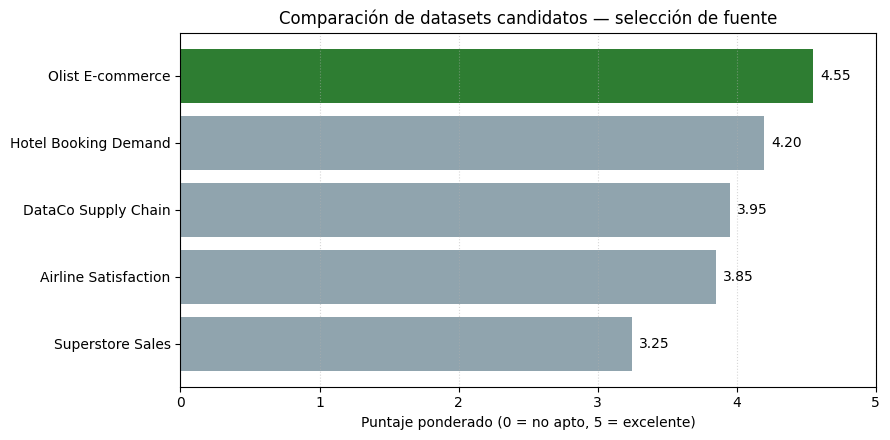

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2E7D32" if v == puntaje_final.max() else "#90A4AE"
          for v in puntaje_final.values]
ax.barh(puntaje_final.index[::-1], puntaje_final.values[::-1], color=colors[::-1])
ax.set_xlim(0, 5)
ax.set_xlabel("Puntaje ponderado (0 = no apto, 5 = excelente)")
ax.set_title("Comparación de datasets candidatos — selección de fuente")
for i, v in enumerate(puntaje_final.values[::-1]):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=10)
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


**Justificación de las calificaciones más relevantes**

- **C3 (Complejidad relacional):** Olist obtiene 5 por ser el único con un
  modelo verdaderamente multi-tabla (9 archivos relacionados). Los demás
  son tablas planas, lo que limita el componente de BI.
- **C2 (Volumen):** DataCo y Olist lideran por volumen de registros;
  Superstore queda rezagado con apenas 10k filas.
- **C5 (Aprendizaje supervisado):** DataCo, Hotel y Airline ofrecen
  targets binarios bien definidos; Olist y Superstore requieren más
  trabajo de definición.
- **C6 (Licencia):** Hotel, Superstore y Airline tienen licencias más
  permisivas (CC0/dominio público); Olist es CC BY-NC-SA (uso académico
  permitido).
- **C7 (Viabilidad técnica):** Olist y DataCo bajan por tamaño y por
  necesidad de joins/codificación especial; los demás son archivos
  pequeños y limpios.


## 8. Recomendación de selección

A partir de la matriz ponderada, el dataset **Brazilian E-Commerce by
Olist** obtiene el puntaje más alto y es el **candidato recomendado**
para las fases siguientes del proyecto.

**Razones principales**

1. **Riqueza relacional única.** Es el único candidato con modelo
   multi-tabla, lo que permite diseñar un esquema dimensional
   (hecho: orden; dimensiones: cliente, producto, vendedor, tiempo,
   geografía) y aprovechar plenamente la asignatura de **Inteligencia de
   Negocios**.
2. **Múltiples problemas de negocio en una sola fuente.** Permite
   formular tanto problemas de **regresión** (tiempo de entrega) como
   de **clasificación** (puntaje de reseña), e incluso de **series de
   tiempo** (demanda agregada), dando flexibilidad en la fase de
   modelado.
3. **Datos reales y representativos** de un marketplace en operación
   (Olist), lo que enriquece la narrativa del proyecto y la
   sustentación.
4. **Alta documentación pública** y comunidad de referencia, lo que
   facilita validar metodologías sin sustituir el trabajo propio.

**Riesgos identificados y mitigación**

| Riesgo | Mitigación |
|---|---|
| Tamaño relativamente grande (~65 MB y joins) | Usar `pandas` con `dtype` controlado y `parquet` en etapas intermedias del ETL. |
| Reseñas en portugués | El análisis NLP es **opcional**; los problemas principales no dependen del texto. |
| Licencia no comercial | Declarar explícitamente el uso académico en la portada del informe. |

**Problema de negocio elegido (preliminar, sujeto a refinamiento en EDA)**

> *"Predecir si un cliente otorgará una reseña positiva (≥ 4 estrellas)
> a partir de las características de la orden, el producto, el vendedor
> y la logística de entrega."*

Este enfoque combina los tres ejes del proyecto: BI (modelo dimensional
y dashboard de satisfacción), AD (limpieza, EDA y visualización de
correlaciones) y AC (clasificación binaria con métricas de precisión,
recall y F1).


## 9. Próximos pasos

1. **Notebook de ETL** (siguiente entregable de la Fase 1):
   - Descarga local del dataset Olist desde Kaggle.
   - Carga de las 9 tablas con tipado controlado.
   - Validaciones de calidad (duplicados, claves foráneas, valores
     nulos, fechas inconsistentes).
   - Construcción de un modelo dimensional preliminar y persistencia
     en formato `parquet`.
2. **Fase 2 — EDA:** análisis de distribuciones, correlaciones y
   anomalías; visualizaciones de tendencias temporales y geográficas.
3. **Fase 3 — BI:** diseño del modelo estrella y construcción del
   dashboard.
4. **Fase 4 — Modelado predictivo:** clasificación de reseña positiva
   con validación cruzada.
5. **Fase 5 — Conclusiones y recomendaciones de negocio.**


## 10. Referencias

- Olist. *Brazilian E-Commerce Public Dataset by Olist*. Kaggle.
  https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
- Shashwat Tiwari. *DataCo Smart Supply Chain for Big Data Analysis*.
  Kaggle.
  https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
- Antonio, N., Almeida, A., & Nunes, L. (2019). *Hotel booking demand
  datasets*. Data in Brief, 22, 41-49. — Publicado en Kaggle como
  https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- Laiba Anwer. *Superstore Sales Dataset*. Kaggle.
  https://www.kaggle.com/datasets/laibaanwer/superstore-sales-dataset
- TJ Klein / mysarahmadbhat. *Airline Passenger Satisfaction*. Kaggle.
  https://www.kaggle.com/datasets/mysarahmadbhat/airline-passenger-satisfaction
